In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dataset_plotting_functions
import os


C:\Users\MacRaeDC\AppData\Local\Temp\ipykernel_25644\2517983103.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Load a random patient

In [53]:
dataset_dir = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Multitox/datasets"
dataset_name = "dataset_dan"
patientFolder = 'patients'

patient_folder_dir = os.path.join(dataset_dir, dataset_name, patientFolder)


patient_ID_set = os.listdir(patient_folder_dir)
patient_ID = patient_ID_set[101]
print(patient_ID)
#patient_ID = '0359912'

# load the images (note that the images are 4D arrays, but the first dimension can be dropped)
CROPPED_CT = np.load(os.path.join(patient_folder_dir, patient_ID, "ct.npy"))[0,:,:,:]
CROPPED_SEGMAP = np.load(os.path.join(patient_folder_dir, patient_ID, "segmentation_map.npy"))[0,:,:,:]
CROPPED_RTDOSE  = np.load(os.path.join(patient_folder_dir, patient_ID, "rtdose.npy"))[0,:,:,:]

5749392


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Plot slices of this patient

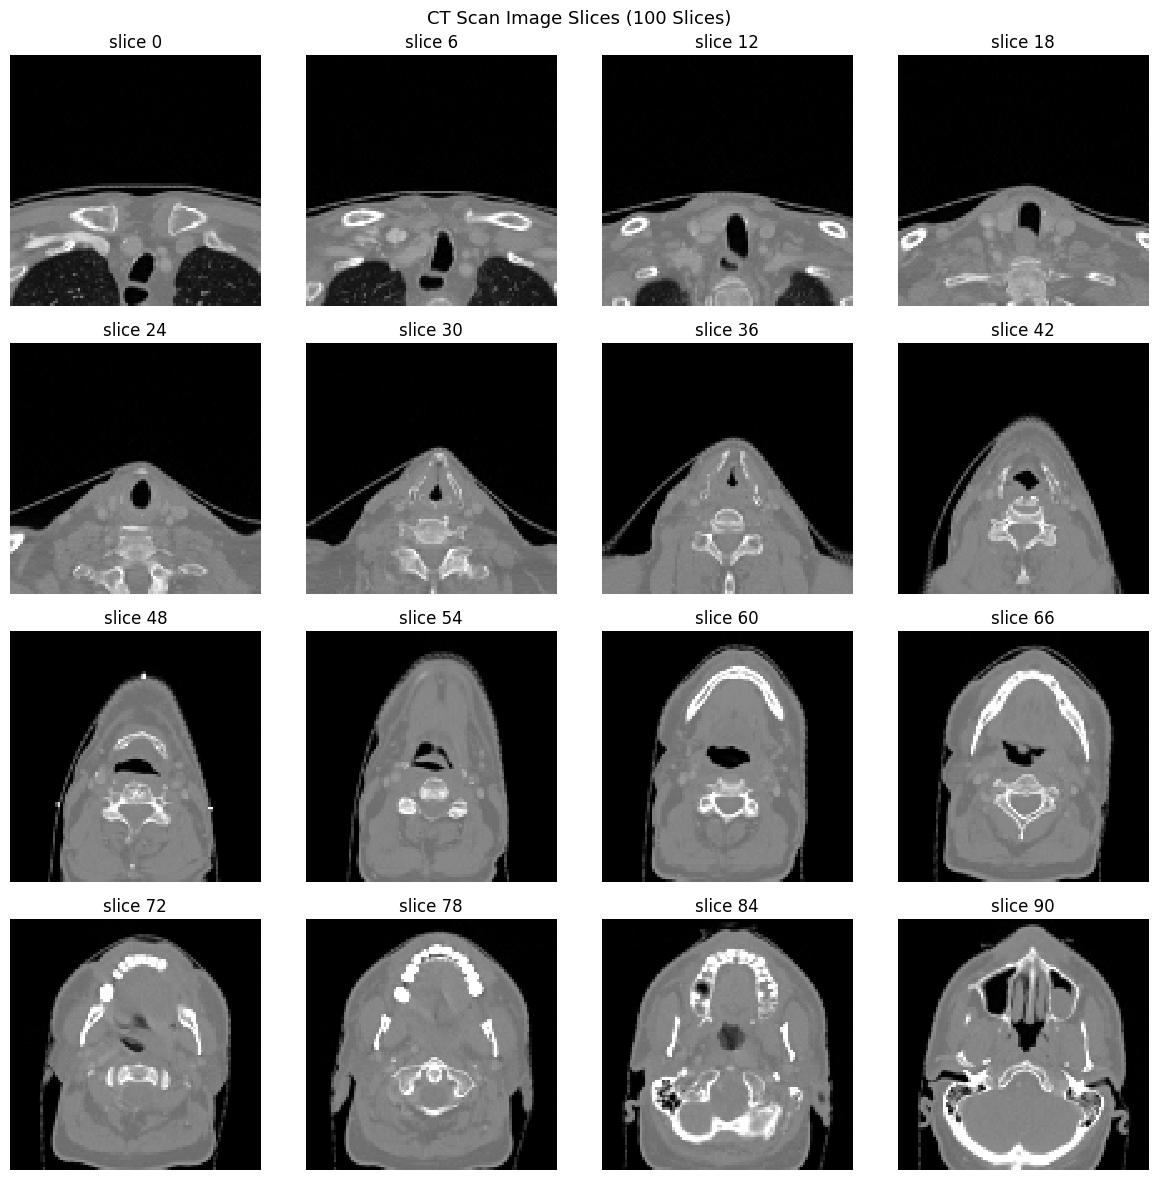

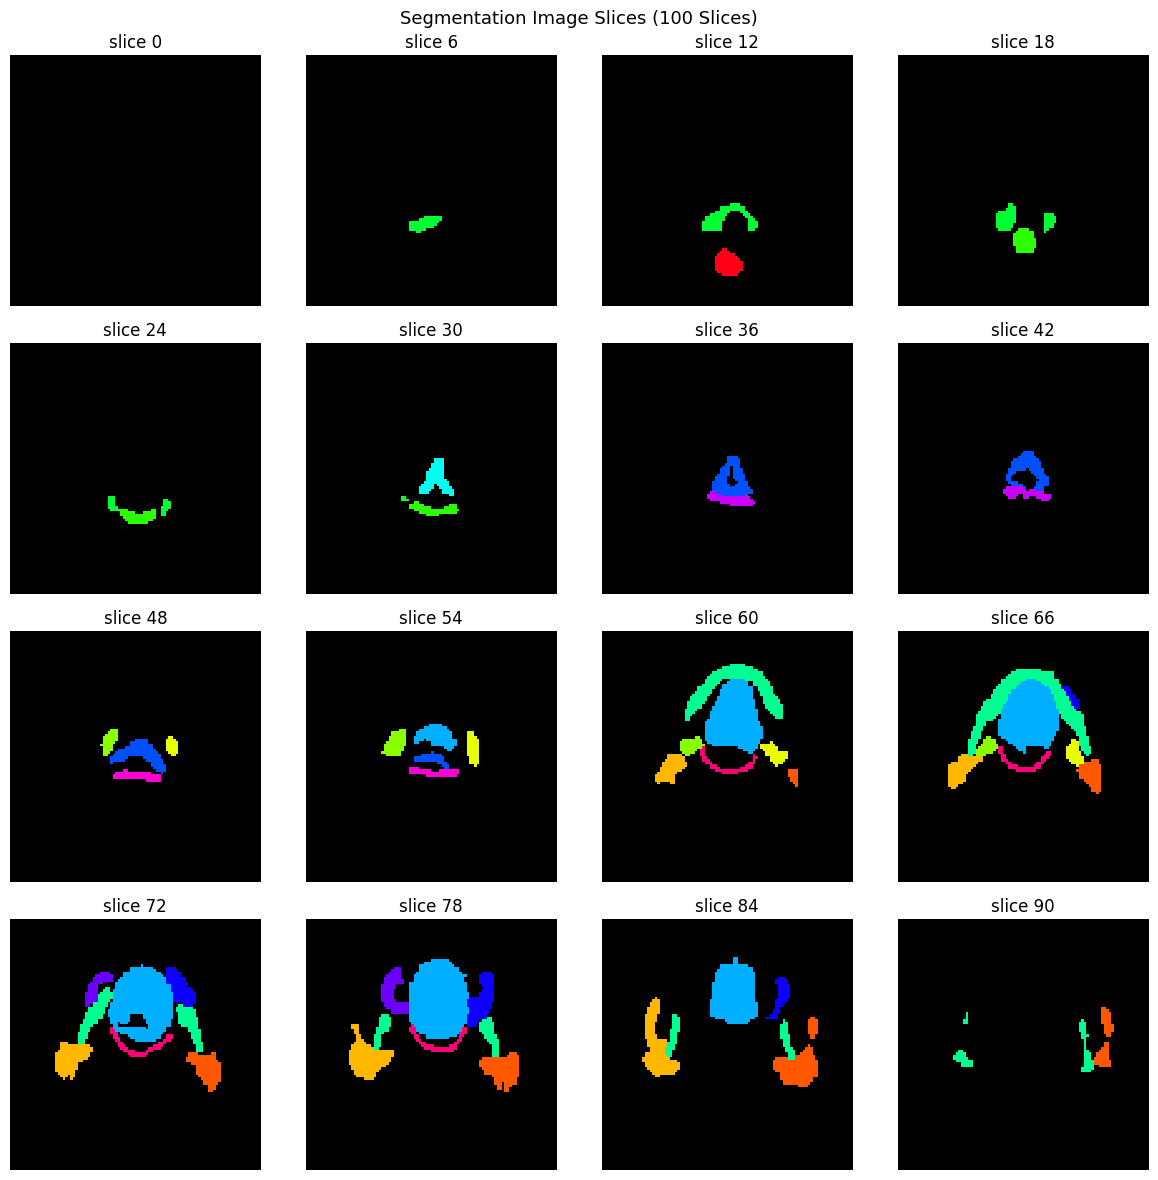

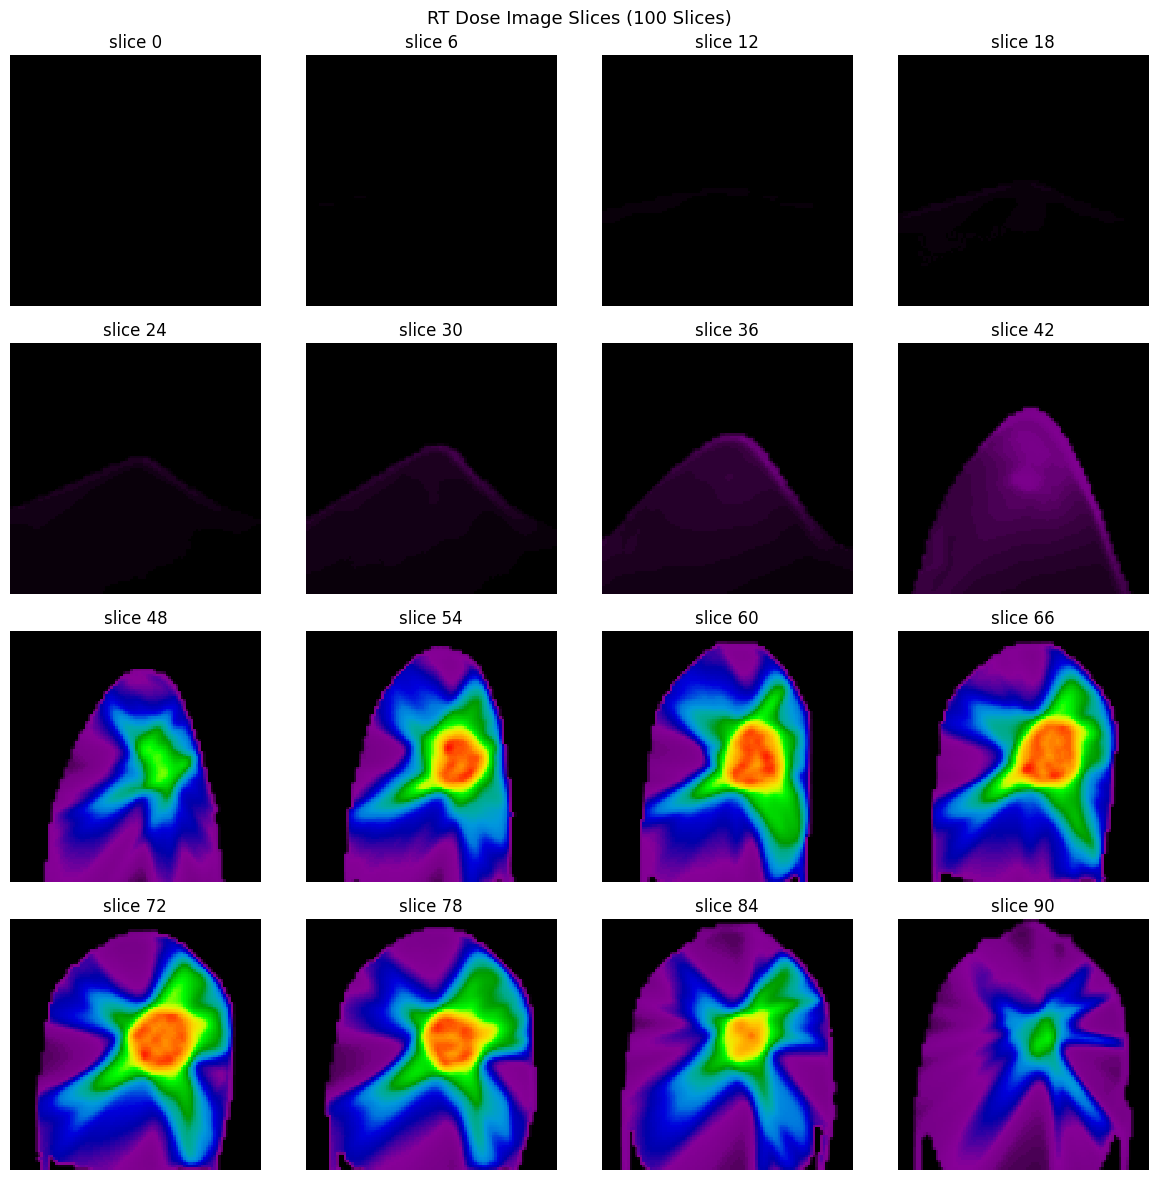

In [54]:
dataset_plotting_functions.show_slices(CROPPED_CT, title="CT Scan Image Slices", padding=0, save_dir=None)

dataset_plotting_functions.show_slices(CROPPED_SEGMAP, title="Segmentation Image Slices", padding=0, SEG=True, save_dir=None)

dataset_plotting_functions.show_slices(CROPPED_RTDOSE, title="RT Dose Image Slices", padding=0, RT=True, save_dir=None)

In [26]:
# BEGIN: value_counts
import numpy as np

value_counts = np.unique(CROPPED_SEGMAP, return_counts=True)
# END: value_counts
value_counts

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       dtype=int16),
 array([951468,   4592,   4482,   1185,   1251,    970,   1881,   8307,
           744,  15593,   2416,   1953,   1303,    867,   1032,   1284,
           672], dtype=int64))

In [48]:
for slice in range(CROPPED_CT.shape[0]):
    #print()
    print(f"slice {slice}:", CROPPED_CT[slice,:,:].mean())
    #print("\n")

slice 0: -653.2425
slice 1: -651.6135
slice 2: -648.5477
slice 3: -645.22
slice 4: -642.7531
slice 5: -640.2763
slice 6: -639.0656
slice 7: -638.4841
slice 8: -636.4623
slice 9: -633.4638
slice 10: -629.1587
slice 11: -624.2318
slice 12: -619.4062
slice 13: -613.0122
slice 14: -606.6207
slice 15: -601.6174
slice 16: -597.1408
slice 17: -595.3038
slice 18: -594.3425
slice 19: -595.7024
slice 20: -598.223
slice 21: -601.4883
slice 22: -604.0524
slice 23: -605.7597
slice 24: -607.3801
slice 25: -608.5852
slice 26: -608.3046
slice 27: -607.6516
slice 28: -606.7484
slice 29: -608.7153
slice 30: -611.0397
slice 31: -609.3613
slice 32: -609.6374
slice 33: -608.2704
slice 34: -607.2285
slice 35: -607.9677
slice 36: -608.7313
slice 37: -607.7103
slice 38: -607.9794
slice 39: -615.2341
slice 40: -620.5209
slice 41: -622.9229
slice 42: -625.2771
slice 43: -624.8319
slice 44: -620.8691
slice 45: -616.3268
slice 46: -610.3386
slice 47: -604.8992
slice 48: -597.6619
slice 49: -589.8565
slice 50: -58

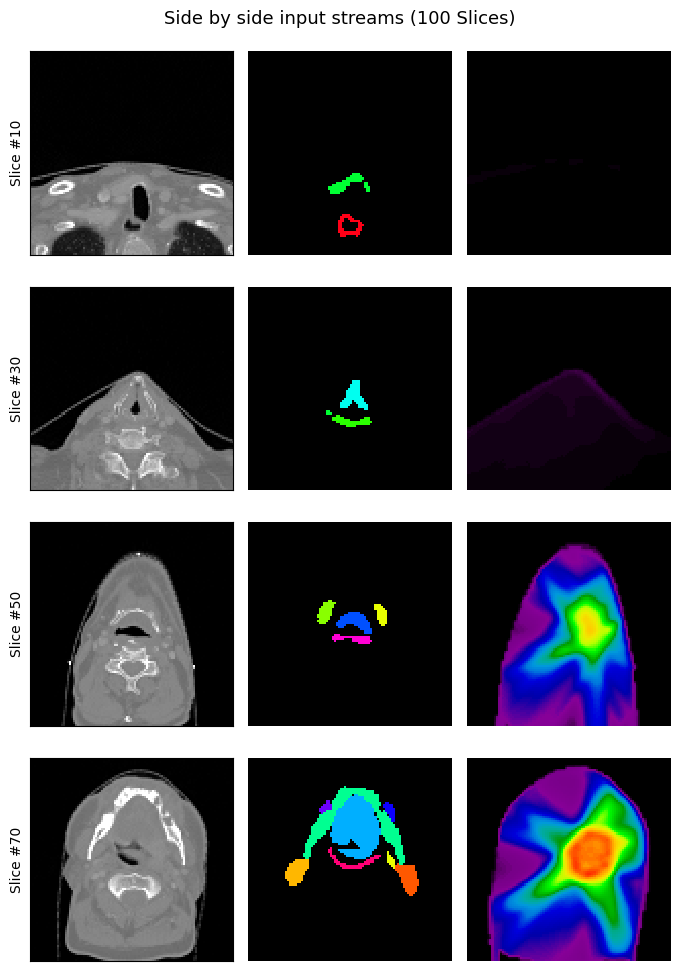

In [28]:
dataset_plotting_functions.show_all_three_inputs(CROPPED_CT, CROPPED_SEGMAP, CROPPED_RTDOSE, title=f"Side by side input streams", rows=4, padding=10, save_dir=None)

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Make a 3D plot


In [29]:
import plotly.graph_objects as go
import numpy as np

def interactive_colored_segmentation_plot(segmentation_mask):
    """
    Create an interactive 3D plot of a segmentation mask array with colored pixels.

    Parameters:
    - segmentation_mask: 3D segmentation mask array with values between 1 and 16.
    """

    plot_size = segmentation_mask.shape[1]
    # Extract non-zero indices and corresponding labels for plotting
    indices = np.column_stack(np.nonzero(segmentation_mask))
    labels = segmentation_mask[indices[:, 0], indices[:, 1], indices[:, 2]]

    # Define a colormap with 16 different colors
    colormap = [
        'red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow',
        'lightblue', 'pink', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightgoldenrodyellow', 'lightgray', 'lightcyan'
    ]

    # Create a legend dictionary to map labels to class names
    legend_dict = {1: 'parotis_li',
                    2: 'parotis_re',
                    3: 'submandibularis_li',
                    4: 'submandibularis_re',
                    5: 'crico',
                    6: 'thyroid',
                    7: 'mandible',
                    8: 'glotticarea',
                    9: 'oralcavity_ext',
                    10: 'supraglottic',
                    11: 'buccalmucosa_li',
                    12: 'buccalmucosa_re',
                    13: 'pcm_inf',
                    14: 'pcm_med',
                    15: 'pcm_sup',
                    16: 'esophagus_cerv'}
    
    layout = go.Layout(
            scene=dict(
                xaxis=dict(title='X Axis', range=[0, plot_size]),
                yaxis=dict(title='Y Axis', range=[0, plot_size]),
                zaxis=dict(title='Z Axis', range=[0, plot_size]),
                aspectratio=dict(x=1, y=1, z=1)
            ),
            showlegend=True,
        )
    # Create a scatter plot with colored markers
    fig = go.Figure(layout=layout)

    for value in legend_dict:
        organ_array = segmentation_mask.copy()
        organ_array[organ_array != value] = 0
        indices = np.column_stack(np.nonzero(organ_array))

        fig.add_trace( go.Scatter3d(
            x=indices[:, 2],  # Assuming the first dimension is along the z-axis
            y=indices[:, 1],  # Assuming the second dimension is along the y-axis
            z=indices[:, 0],  # Assuming the third dimension is along the x-axis
            mode='markers',
            marker=dict(
                #size=4,
                color=colormap[value-1],  # Use the mapped colors
            ),
            marker_symbol='square',
            #text=legend_labels[value],  # Assign text for each point (used for legend)
            name=legend_dict[value],  # Name of the legend
            showlegend=True
    ))

    # Create the figure and add the trace
    fig.update_layout(showlegend=True,
                      #autosize=False,
                      #width=1000,
                      height=800
        )

    # Show the interactive plot
    
    fig.show()
    fig.write_html(file=f"3D RTSTRUCT plot {patient_ID}.html")

interactive_colored_segmentation_plot(CROPPED_SEGMAP)


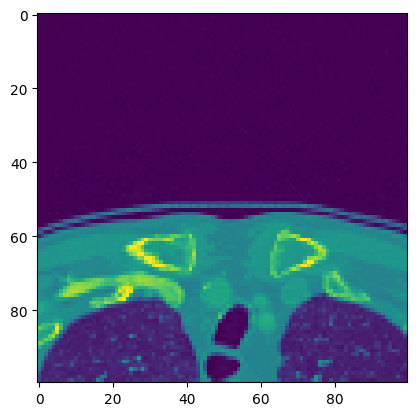

In [40]:
plt.imshow(CROPPED_CT[0,:,:])

In [47]:
CROPPED_CT[0,:,:].mean()

-653.2425

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## See if a CT changed

In [18]:
dir1 = "MT_dataset/patients/"
dir2 = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/preprocessed/dataset_full"
dir3 = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/HungChu/Data/PRI2MA/dataset_new/dataset_full"
os.listdir(dir2)

patient = "0851961"

CTs = []
dir_list = [dir1, dir2, dir3]

for dir in dir_list:
    CTs.append(np.load(os.path.join(dir, patient, "ct.npy"))[0,:,:,:])

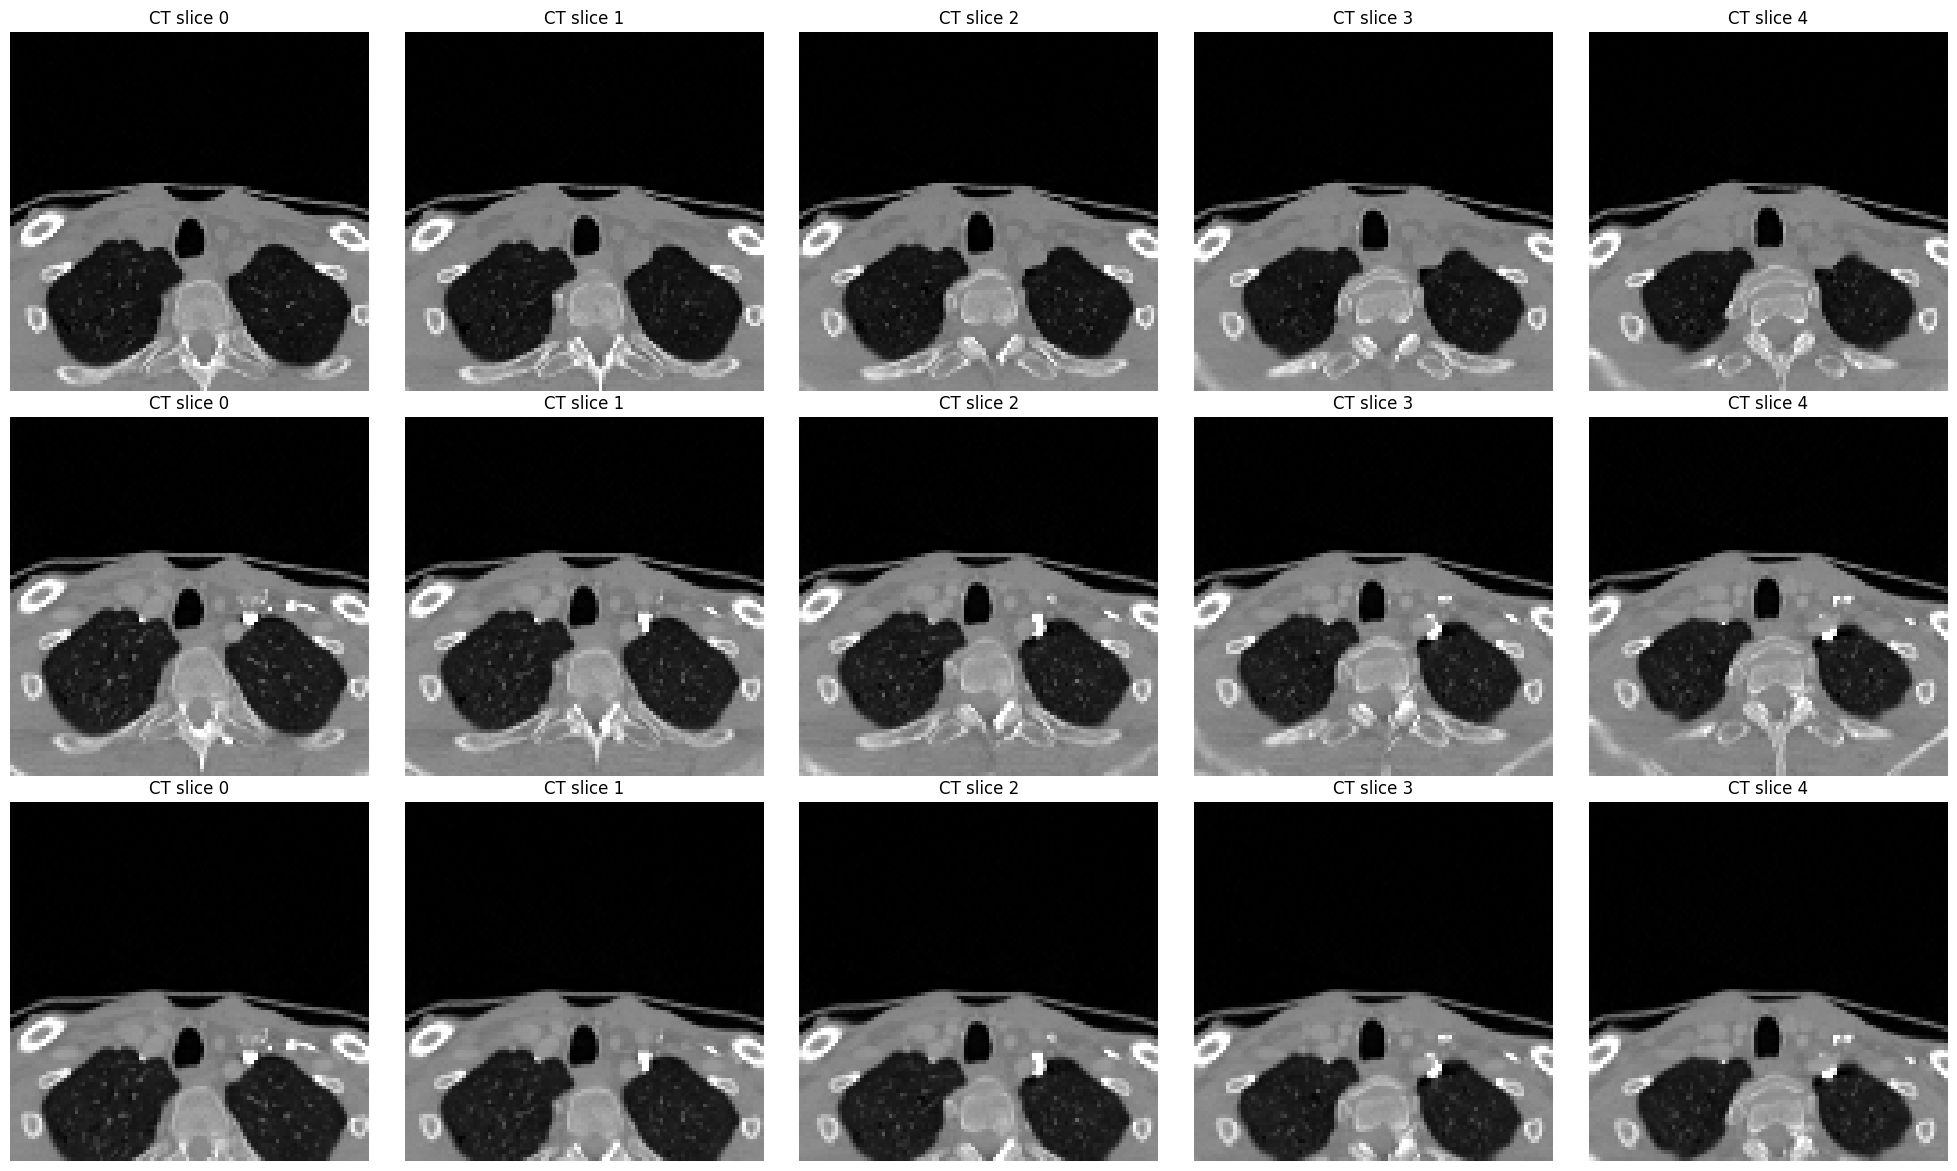

In [19]:
import matplotlib.gridspec as gridspec

slices = [20, 50, 60, 70, 80]
row_count = len(dir_list)
slice_count = len(slices)

plot_width = 100
plot_height = 100

fig_width = plot_width * slice_count / 20  # Divide by 80 to convert from pixels to inches
fig_height = plot_height * row_count / 20  # Divide by 80 to convert from pixels to inches

# Create a gridspec to add a colorbar axis
fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(row_count, slice_count, width_ratios=[1]*slice_count, hspace=0, wspace=0.1, figure=fig)


# Create subplots
axs = [[plt.subplot(gs[i, j]) for j in range(slice_count)] for i in range(row_count)]

for i in range(row_count):
    ax = axs[i]
    for j in range(5):
        ax[j].imshow(CTs[i][j,:,:], cmap='gray')
        ax[j].set_title(f"CT slice {j}")
        ax[j].axis('off')
